# Topic 4 — PCA and its effect on classification

**Q1:** Dry Bean dataset (16 features, 7 classes) — Random Forest before vs after PCA
**Q2:** Breast Cancer Wisconsin — SVM before vs after PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

---
## Question 1 — Dry Bean dataset

### Step 1: Load and inspect

In [2]:
df = pd.read_csv("datasets/Dry_Bean.csv")

print("Shape          :", df.shape)
print("Missing values :", df.isna().sum().sum())
print("\nClass distribution:\n", df["Class"].value_counts())
df.head()

Shape          : (13611, 17)
Missing values : 0

Class distribution:
 Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### Step 2: Quick EDA

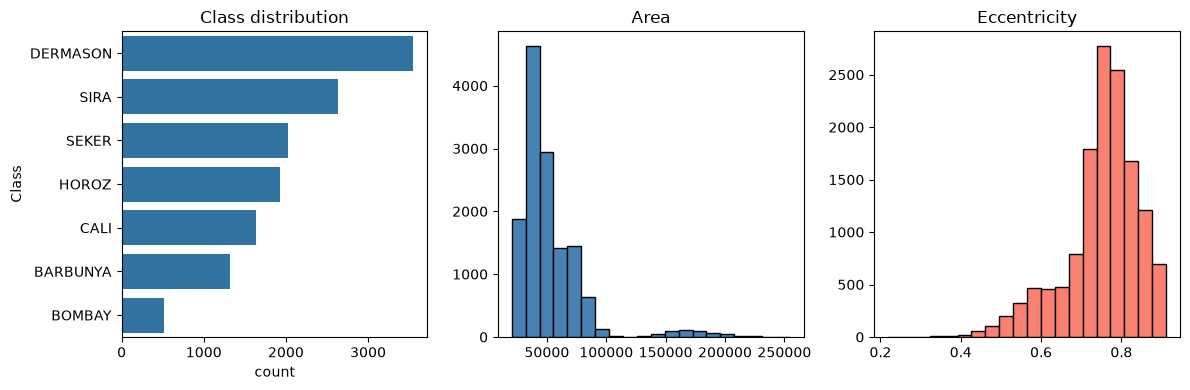

In [3]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(y="Class", data=df, order=df["Class"].value_counts().index)
plt.title("Class distribution")

plt.subplot(1, 3, 2)
plt.hist(df["Area"], bins=20, color="steelblue", edgecolor="black")
plt.title("Area")

plt.subplot(1, 3, 3)
plt.hist(df["Eccentricity"], bins=20, color="salmon", edgecolor="black")
plt.title("Eccentricity")

plt.tight_layout()
plt.show()

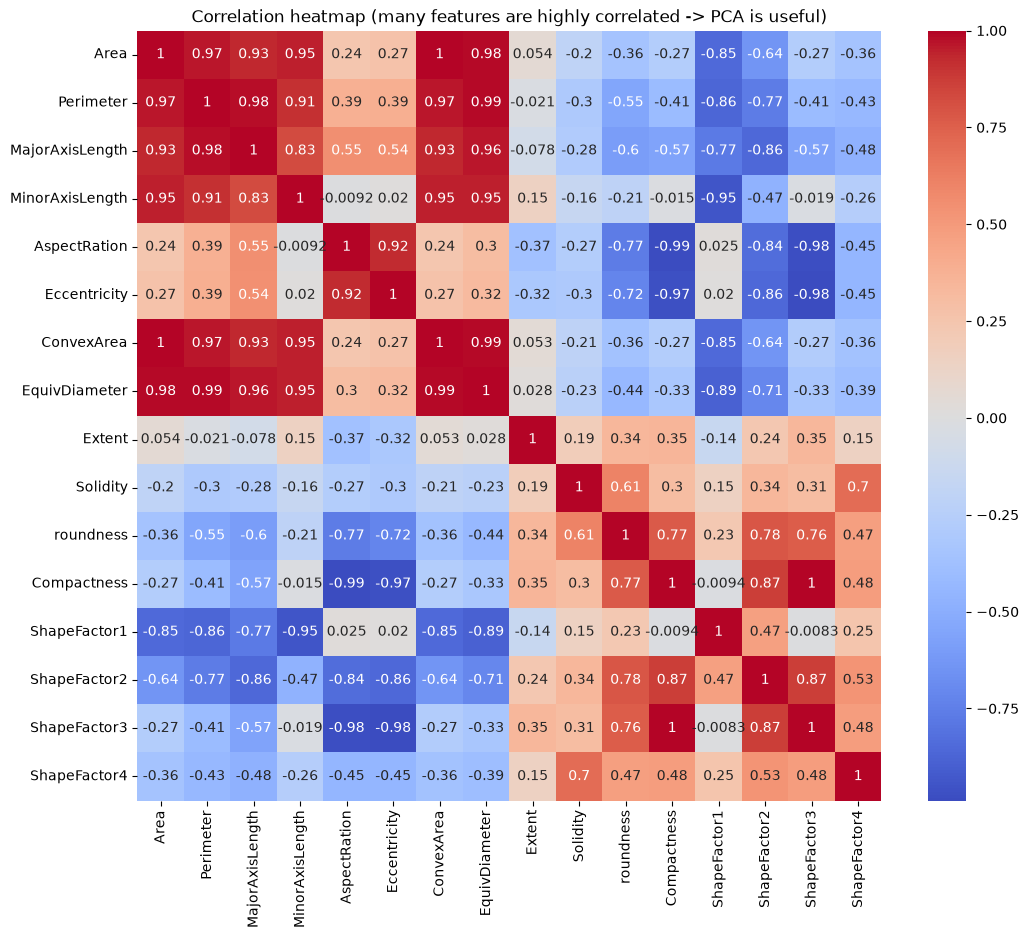

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(columns=["Class"]).corr(), cmap="coolwarm", annot=True)
plt.title("Correlation heatmap (many features are highly correlated -> PCA is useful)")
plt.show()

### Step 3: Split and scale (PCA requires standardized features)

In [5]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

### Step 4: Baseline classifier on the original 16 features

In [6]:
def rf_accuracy(Xtr, Xte, ytr, yte):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(Xtr, ytr)
    return accuracy_score(yte, model.predict(Xte))

acc_before = rf_accuracy(X_train_s, X_test_s, y_train, y_test)
print("Accuracy with all 16 features:", round(acc_before, 4))

Accuracy with all 16 features: 0.9207


### Step 5: Apply PCA and plot the explained variance

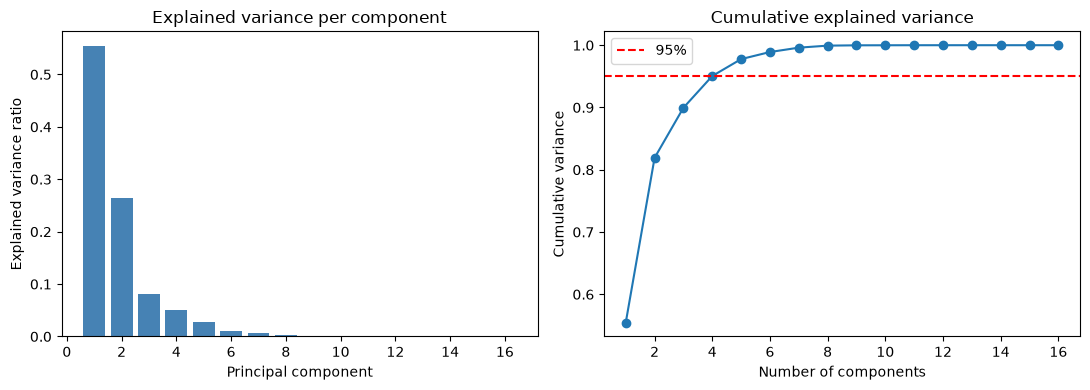

Components needed for 95% variance: 4


In [7]:
pca_full = PCA().fit(X_train_s)
ratio = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratio)

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(ratio) + 1), ratio, color="steelblue")
plt.xlabel("Principal component"); plt.ylabel("Explained variance ratio")
plt.title("Explained variance per component")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative) + 1), cumulative, "o-")
plt.axhline(0.95, color="red", linestyle="--", label="95%")
plt.xlabel("Number of components"); plt.ylabel("Cumulative variance")
plt.title("Cumulative explained variance"); plt.legend()

plt.tight_layout()
plt.show()

n_components = int(np.argmax(cumulative >= 0.95) + 1)
print("Components needed for 95% variance:", n_components)

### Step 6: Train the same classifier on the PCA features and compare

              Setting  n_features  Accuracy
0   Original features          16    0.9207
1  PCA (4 components)           4    0.8931


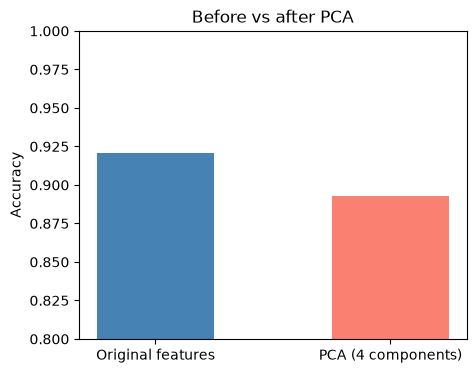

In [8]:
pca = PCA(n_components=n_components).fit(X_train_s)
X_train_p, X_test_p = pca.transform(X_train_s), pca.transform(X_test_s)

acc_after = rf_accuracy(X_train_p, X_test_p, y_train, y_test)

summary = pd.DataFrame({
    "Setting": ["Original features", f"PCA ({n_components} components)"],
    "n_features": [X.shape[1], n_components],
    "Accuracy": [round(acc_before, 4), round(acc_after, 4)]
})
print(summary)

plt.figure(figsize=(5, 4))
plt.bar(summary["Setting"], summary["Accuracy"], color=["steelblue", "salmon"], width=0.5)
plt.ylim(0.8, 1.0); plt.ylabel("Accuracy"); plt.title("Before vs after PCA")
plt.show()

### Step 7: Visualize the first two principal components

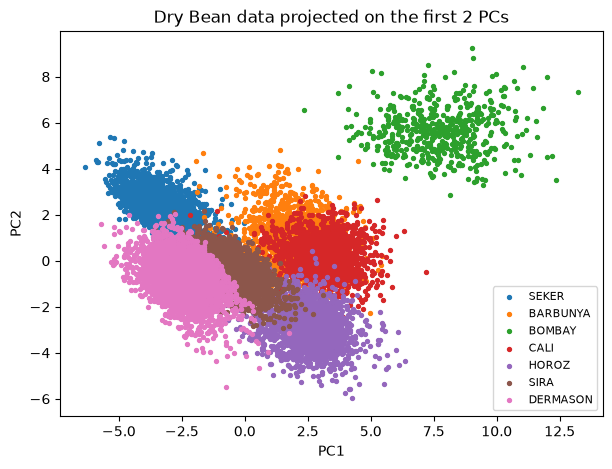

In [9]:
X_2d = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))

plt.figure(figsize=(7, 5))
for c in y.unique():
    plt.scatter(X_2d[y == c, 0], X_2d[y == c, 1], s=8, label=c)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(fontsize=8)
plt.title("Dry Bean data projected on the first 2 PCs")
plt.show()

**Conclusion (Q1).** 16 features are compressed to about 4 components that still keep 95% of the
variance (the features are heavily correlated — Area, Perimeter, ConvexArea, EquivDiameter all
measure size). Accuracy drops only slightly (≈0.92 → ≈0.89), so PCA gives a 4× smaller feature space
and faster training for a small accuracy cost. If maximum accuracy matters, keep the original
features; if speed/storage matters, PCA is worth it.

---
## Question 2 — Breast Cancer Wisconsin (SVM before vs after PCA)

### Step 1: Load, clean, standardize

In [10]:
bc = pd.read_csv("datasets/breast-cancer-wisconsin.csv")
bc = bc.replace("?", np.nan).drop(columns=["id"]).astype(float)
bc = bc.fillna(bc.median())

print("Shape:", bc.shape, "| Missing:", bc.isna().sum().sum())

X = bc.drop(columns=["class"])
y = (bc["class"] == 4).astype(int)      # 1 = malignant

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

Shape: (699, 10) | Missing: 0


### Step 2: SVM on the original features

In [11]:
def svm_scores(name, Xtr, Xte, ytr, yte):
    model = SVC(kernel="rbf", random_state=42)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {"Setting": name,
            "Accuracy": accuracy_score(yte, pred),
            "Precision": precision_score(yte, pred),
            "Recall": recall_score(yte, pred),
            "F1": f1_score(yte, pred)}

before = svm_scores("Original (9 features)", X_train_s, X_test_s, y_train, y_test)
print(before)

{'Setting': 'Original (9 features)', 'Accuracy': 0.9571428571428572, 'Precision': 0.9375, 'Recall': 0.9375, 'F1': 0.9375}


### Step 3: PCA — cumulative variance and component selection

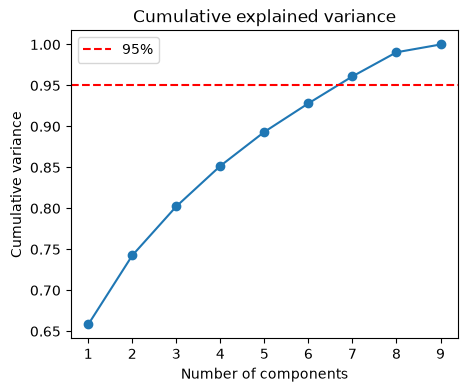

Components for 95% variance: 7


In [12]:
pca_full = PCA().fit(X_train_s)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(5, 4))
plt.plot(range(1, len(cumulative) + 1), cumulative, "o-")
plt.axhline(0.95, color="red", linestyle="--", label="95%")
plt.xlabel("Number of components"); plt.ylabel("Cumulative variance")
plt.title("Cumulative explained variance"); plt.legend()
plt.show()

k = int(np.argmax(cumulative >= 0.95) + 1)
print("Components for 95% variance:", k)

### Step 4: SVM on the PCA features + comparison

                 Setting  Accuracy  Precision  Recall      F1
0  Original (9 features)    0.9571     0.9375  0.9375  0.9375
1     PCA (7 components)    0.9571     0.9200  0.9583  0.9388


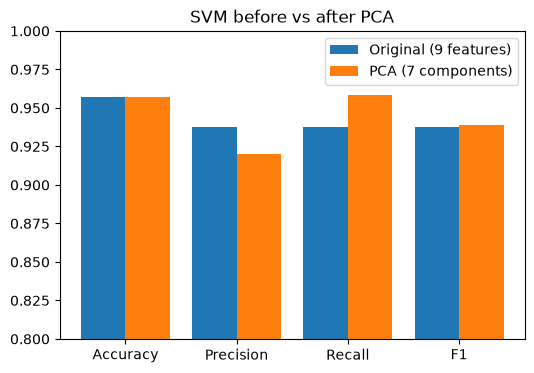

In [13]:
pca = PCA(n_components=k).fit(X_train_s)
after = svm_scores(f"PCA ({k} components)",
                   pca.transform(X_train_s), pca.transform(X_test_s), y_train, y_test)

results = pd.DataFrame([before, after]).round(4)
print(results)

metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics))

plt.figure(figsize=(6, 4))
plt.bar(x - 0.2, results.loc[0, metrics], width=0.4, label=results.loc[0, "Setting"])
plt.bar(x + 0.2, results.loc[1, metrics], width=0.4, label=results.loc[1, "Setting"])
plt.xticks(x, metrics); plt.ylim(0.8, 1.0); plt.legend()
plt.title("SVM before vs after PCA")
plt.show()

### Step 5: Visualize the first two principal components

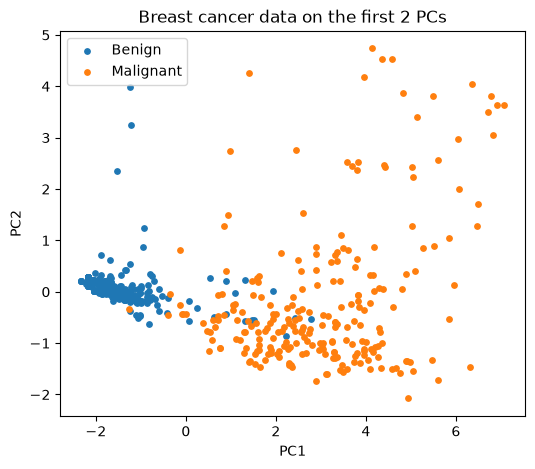

In [14]:
X_2d = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[y == 0, 0], X_2d[y == 0, 1], s=15, label="Benign")
plt.scatter(X_2d[y == 1, 0], X_2d[y == 1, 1], s=15, label="Malignant")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.title("Breast cancer data on the first 2 PCs")
plt.show()

**Conclusion (Q2).** PCA keeps the SVM performance essentially unchanged (≈0.957 accuracy, F1 ≈0.94)
while using fewer components, so dimensionality reduction is beneficial here: no information that
matters for the diagnosis is lost. The 2-component scatter plot also shows the two classes separate
almost completely along PC1, which explains why even a small number of components is enough.